# Three-dimensional phase unwrapping: does the third axis help?

*An undergraduate-level study of the volume solvers in Parvaneh, measured on one
deterministic experiment.*

---

### The question

A wrapped phase map hides an integer at every pixel: what is measured is the
true phase plus an unknown whole number of $2\pi$ turns. **Unwrapping** means
choosing those integers so that the recovered surface is smooth.

Real data rarely arrives as a single map. It arrives as a **volume**: the same
area imaged on many dates, or a stack of interferograms from slightly different
orbits. There are then two ways to work.

1. **Slice by slice.** Unwrap each 2-D map with the algorithms already in the
   package, and accept whatever offsets appear between slices.
2. **Jointly.** Unwrap the whole volume at once, so each slice is also evidence
   for its neighbours.

The joint solve is heavier, so it has to earn its keep. This notebook answers,
with numbers, three questions:

* what exactly does the third axis fix?
* when does it *not* help?
* what does it cost?

Nothing is hidden. One synthetic truth, one noise model, and four separate error
measures, so that no single number can flatter a solver.

## 1. The experiment

Ground truth is built so that every interesting behaviour is present and every
number is known exactly:

$$u(x, y, k) = \underbrace{0.12\,x + 0.05\,y}_{\text{tilt}}
+ \underbrace{10\,e^{-\left((x-23.5)^2+(y-23.5)^2\right)/7^2}}_{\text{a hill}}
+ \underbrace{0.15\,k}_{\text{drift along the stack}}$$

where $k = 0, 1, \dots, 7$ is the slice index. The tilt and the hill are things a
2-D solver can recover from one slice. The drift is **not**: $0.15$ radians per
slice is a constant added to a whole plane, and a wrapped map carries no
information about a constant. Only a neighbour in $k$ can supply it. That
asymmetry is the subject of this notebook.

The measurement is the wrapped truth plus wrapped Gaussian noise of standard
deviation $\sigma$:

$$\psi = \operatorname{wrap}\!\left(u + \sigma\,\mathcal{N}(0,1)\right),
\qquad
\operatorname{wrap}(\phi) = \phi - 2\pi\left\lfloor
\frac{\phi + \pi}{2\pi}\right\rfloor .$$

$\sigma = 0$ is a perfect measurement, $\sigma \approx 0.5$ rad is a good
interferogram, and $\sigma > 1$ rad is a poor one in which fringes begin to be
unrecoverable. We keep $\sigma$ as the single knob of the study.

The helper functions come straight from the command-line benchmark
`benchmarks/benchmark_nd.py`, so the numbers here and the numbers in that script
cannot disagree. Their docstrings are printed below.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd().resolve()
ROOT = HERE if (HERE / 'pyproject.toml').is_file() else HERE.parent
for extra in (ROOT / 'src', ROOT / 'benchmarks'):
    if extra.is_dir() and str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

from parvaneh import (SAKURA_DIVERGING, available_backends,
                      pixel_reliability, reliability_unwrap, unwrap,
                      wrap_phase)
from benchmark_nd import build_volume, metrics, per_slice, timed

print('repository root:', ROOT)
print('available backends:', available_backends())
for function in (build_volume, metrics):
    print()
    print(function.__doc__.strip())

repository root: /home/mohammad/Software/Parvaneh
available backends: {'numpy': True, 'blas': True, 'numba': True, 'cython': False, 'cupy': False}

Return the truth and its wrapped, noisy version.

    The truth rises by 0.12 radians per column and 0.05 radians per row, plus
    a Gaussian hill in the middle and a drift of ``drift`` radians per slice.
    The noise is Gaussian with standard deviation ``sigma``, and the sum is
    wrapped into ``(-pi, pi]``, exactly as a measured interferogram would be.

Compare a volume estimate with the truth slice by slice.


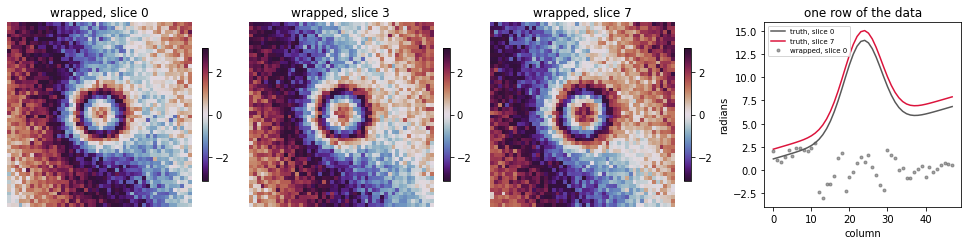

volume shape (rows, columns, slices): (48, 48, 8)
truth spans 15.03 rad, which is 2.4 fringes
the drift alone adds 1.05 rad from the first slice to the last


In [2]:
truth, wrapped = build_volume(48, 48, 8, 0.45, seed=1)


def aligned_error(estimate, reference=truth):
    """Error after removing the one constant that unwrapping cannot know."""
    error = np.asarray(estimate, dtype=float) - np.asarray(reference, float)
    return error - error.mean()


figure, axes = plt.subplots(1, 4, figsize=(13.5, 3.3),
                            constrained_layout=True)
for axis, index in zip(axes[:3], (0, 3, 7)):
    artist = axis.imshow(wrapped[:, :, index], origin='lower',
                         cmap='twilight_shifted', vmin=-np.pi, vmax=np.pi)
    axis.set_title('wrapped, slice %d' % index)
    axis.axis('off')
    figure.colorbar(artist, ax=axis, shrink=.72)
row = 24
axes[3].plot(truth[row, :, 0], color='0.35', label='truth, slice 0')
axes[3].plot(truth[row, :, 7], color='crimson', label='truth, slice 7')
axes[3].plot(wrapped[row, :, 0], 'o', ms=3, color='0.35', alpha=.55,
             label='wrapped, slice 0')
axes[3].set_title('one row of the data')
axes[3].set_xlabel('column'); axes[3].set_ylabel('radians')
axes[3].legend(fontsize=7)
plt.show()

print('volume shape (rows, columns, slices):', wrapped.shape)
print('truth spans %.2f rad, which is %.1f fringes'
      % (truth.max() - truth.min(),
         (truth.max() - truth.min()) / (2 * np.pi)))
print('the drift alone adds %.2f rad from the first slice to the last'
      % (truth[0, 0, -1] - truth[0, 0, 0]))

### Why four numbers, not one?

Suppose a solver recovers the surface perfectly inside every slice, but leaves
slice 7 a whole $2\pi$ above slice 6. Is that a good answer? It is excellent
locally and disastrous globally. A single RMSE cannot say both things, so we
report four numbers, all in radians.

| measure | what it is | what it exposes |
| --- | --- | --- |
| `aligned_rmse_rad` | RMS error after removing **one** constant from the whole volume | the honest overall score |
| `wrong_fringe_fraction` | fraction of voxels off by more than $\pi$ | the damage a user actually sees, because a patch jumps by a whole fringe |
| `slice_offset_spread_rad` | standard deviation, over slices, of each slice's own mean error | the **tie** between slices: large when slices were never connected |
| `local_rmse_rad` | RMS error after removing **each slice's own** mean error | the shape *inside* slices only |

Removing one constant is legitimate: unwrapping is only ever defined up to a
single global additive constant, since $u$ and $u + c$ wrap identically. Every
other offset is a genuine mistake.

2-D, slice by slice  RMSE  3.075 | wrong  38.5% | offsets  3.042 | local  0.447
3-D, whole volume    RMSE  0.447 | wrong   0.0% | offsets  0.006 | local  0.447


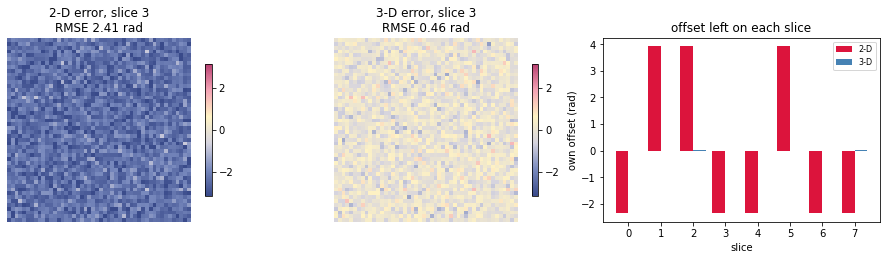

In [3]:
flat = per_slice(wrapped, reliability_unwrap)
joint = reliability_unwrap(wrapped, backend='numba')

for name, estimate in (('2-D, slice by slice', flat),
                       ('3-D, whole volume', joint)):
    numbers = metrics(estimate, truth)
    print('%-20s RMSE %6.3f | wrong %5.1f%% | offsets %6.3f | local %6.3f'
          % (name, numbers['aligned_rmse_rad'],
             100 * numbers['wrong_fringe_fraction'],
             numbers['slice_offset_spread_rad'],
             numbers['local_rmse_rad']))

figure, axes = plt.subplots(1, 3, figsize=(13.5, 3.5),
                            constrained_layout=True)
for axis, estimate, title in ((axes[0], flat, '2-D error, slice 3'),
                              (axes[1], joint, '3-D error, slice 3')):
    image = aligned_error(estimate)[:, :, 3]
    artist = axis.imshow(image, origin='lower', cmap=SAKURA_DIVERGING,
                         vmin=-np.pi, vmax=np.pi)
    axis.set_title('%s\nRMSE %.2f rad'
                   % (title, np.sqrt((image ** 2).mean())))
    axis.axis('off')
    figure.colorbar(artist, ax=axis, shrink=.72)
offsets = [aligned_error(estimate).mean(axis=(0, 1))
           for estimate in (flat, joint)]
axes[2].bar(np.arange(8) - .2, offsets[0], .4, color='crimson', label='2-D')
axes[2].bar(np.arange(8) + .2, offsets[1], .4, color='steelblue', label='3-D')
axes[2].set_xlabel('slice'); axes[2].set_ylabel('own offset (rad)')
axes[2].set_title('offset left on each slice'); axes[2].legend(fontsize=8)
plt.show()

Read the right-hand panel first. The 2-D run has left a different offset on every
slice -- as much as 3.9 rad, about 0.6 of a fringe, on slices whose sign flips
from one slice to the next. Inside the slices it was fine: its `local_rmse_rad`
of 0.447 rad is the same as the 3-D run's. The 3-D run has no such offsets: the
slices are tied together, and only the one global constant that unwrapping can
never know remains. That is the honest, visible benefit of the third axis -- and
it is exactly what the two middle columns of the table in the next section
quantify.

## 2. Three-dimensional least squares

The solver behind `unwrap` is least squares, and it generalises to any number of
axes without a single new parameter. The idea in one paragraph: every pair of
neighbouring voxels gives one equation

$$u_b - u_a = \operatorname{wrap}(\psi_b - \psi_a),$$

which is what we wish were true. Wrapping has already spoiled some equations, so
we cannot satisfy them all. Instead we minimise the total squared mismatch,

$$E[u] = \sum_{\text{pairs}} \left(u_b - u_a - \operatorname{wrap}(\psi_b
- \psi_a)\right)^2 ,$$

whose normal equations are the discrete Poisson equation

$$\nabla^2 u = \rho, \qquad \rho \text{ built from the wrapped differences.}$$

$$(\nabla^2 u)_{ijk} = u_{i+1,j,k} + u_{i-1,j,k} + u_{i,j+1,k} + u_{i,j-1,k}
+ u_{i,j,k+1} + u_{i,j,k-1} - 6\,u_{ijk}.$$

Nothing about this depends on there being three indices: adding a fourth axis
adds one more pair of terms on the left. The package exploits that literally --
`unwrap` is one code path for any number of axes -- and solves the Poisson
equation exactly with a **discrete cosine transform** (DCT), using the mirrored
boundary condition for which the cosine basis diagonalises the Laplacian. The
cost is that of a few FFTs, i.e. $O(N \log N)$ in the number of voxels.

The decisive difference between the 2-D and 3-D cases is not the cost. It is the
**null space**:

* For independent 2-D solves, every slice has its own free additive constant.
  The leftover constants are then whatever the algorithm's normalisation makes
  them, and the true relative offsets between slices -- our drift -- are lost
  forever.
* For one volume, there is a *single* free constant, shared by every slice. The
  relative offsets are part of the solution and are recovered.

The noiseless case makes this unmistakable, so let us look at it first.

2-D least squares    RMSE  0.344 | wrong   0.0% | offsets  0.344 | local  0.000
3-D least squares    RMSE  0.000 | wrong   0.0% | offsets  0.000 | local  0.000


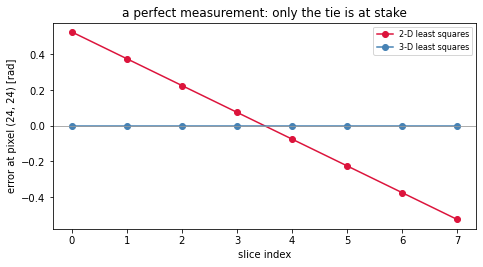

In [4]:
truth0, wrapped0 = build_volume(48, 48, 8, 0.0, seed=1)

for name, estimate in (('2-D least squares', per_slice(wrapped0, unwrap)),
                       ('3-D least squares', unwrap(wrapped0))):
    numbers = metrics(estimate, truth0)
    print('%-20s RMSE %6.3f | wrong %5.1f%% | offsets %6.3f | local %6.3f'
          % (name, numbers['aligned_rmse_rad'],
             100 * numbers['wrong_fringe_fraction'],
             numbers['slice_offset_spread_rad'], numbers['local_rmse_rad']))

pixel = (24, 24)
figure, axis = plt.subplots(figsize=(6.6, 3.6), constrained_layout=True)
for name, estimate, colour in (
        ('2-D least squares', per_slice(wrapped0, unwrap), 'crimson'),
        ('3-D least squares', unwrap(wrapped0), 'steelblue')):
    axis.plot(aligned_error(estimate)[pixel], 'o-', color=colour, label=name)
axis.axhline(0.0, color='0.6', lw=.8)
axis.set_xlabel('slice index')
axis.set_ylabel('error at pixel (24, 24) [rad]')
axis.set_title('a perfect measurement: only the tie is at stake')
axis.legend(fontsize=8)
plt.show()

On perfect data, 2-D least squares solves each slice exactly -- its
`local_rmse_rad` is zero -- and yet its overall answer is off by 0.344 rad,
because it discarded the drift. That number is not a coincidence: the drift has
spread $0.15 \times \operatorname{std}(0, 1, \dots, 7) = 0.344$. Its error at a
single pixel is a straight line in the slice index: the shape of the drift,
missing. The 3-D solve recovers the whole volume, drift included, to machine
precision.

That is the cleanest possible statement of what the third axis is for. Two
consequences follow immediately, and both are worth memorising:

* **The third axis is only as good as its meaning.** It helps when consecutive
  slices really are neighbours whose phase changes smoothly. If a stack mixes
  unrelated acquisitions, or contains a violent change between two slices, the
  joint solve will happily average the disagreement into both.
* **Averaging over slices costs time.** The joint solve is still a Poisson
  solve, so nothing catastrophic happens, but its DCT is over a larger array.

2-D least squares    RMSE  0.565 | wrong   0.0% | offsets  0.344 | local  0.448
3-D least squares    RMSE  0.447 | wrong   0.0% | offsets  0.006 | local  0.447


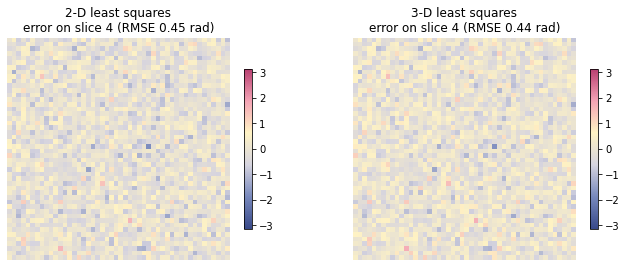

In [5]:
for name, estimate in (('2-D least squares', per_slice(wrapped, unwrap)),
                       ('3-D least squares', unwrap(wrapped))):
    numbers = metrics(estimate, truth)
    print('%-20s RMSE %6.3f | wrong %5.1f%% | offsets %6.3f | local %6.3f'
          % (name, numbers['aligned_rmse_rad'],
             100 * numbers['wrong_fringe_fraction'],
             numbers['slice_offset_spread_rad'], numbers['local_rmse_rad']))

figure, axes = plt.subplots(1, 2, figsize=(9.6, 3.6), constrained_layout=True)
for axis, estimate, title in ((axes[0], per_slice(wrapped, unwrap),
                               '2-D least squares'),
                              (axes[1], unwrap(wrapped),
                               '3-D least squares')):
    image = aligned_error(estimate)[:, :, 4]
    artist = axis.imshow(image, origin='lower', cmap=SAKURA_DIVERGING,
                         vmin=-np.pi, vmax=np.pi)
    axis.set_title('%s\nerror on slice 4 (RMSE %.2f rad)'
                   % (title, np.sqrt((image ** 2).mean())))
    axis.axis('off')
    figure.colorbar(artist, ax=axis, shrink=.72)
plt.show()

This is the plot to compare with the noiseless one. Least squares is a
least-squares estimator, so it spreads every disagreement over the whole volume
rather than leaving it where it happened: the error map stops being a smooth
tilt and starts to look like a lightly blurred copy of the noise. The 3-D panel
is no longer a shifted version of the 2-D one -- the 0.344 rad tilt is gone --
but at this noise level the *local* error is the same 0.45 rad in both panels,
because there is still four neighbours' worth of evidence inside a slice. The
extra axis bought registration here, not shape. Section 5 shows where that
changes.

## 3. Three-dimensional reliability sorting

Least squares assumes the wrapped differences it is given are mostly right and
treats every disagreement as noise. The second family in Parvaneh, reliability
sorting, makes no such assumption. It follows the method of Herraez, Burton,
Lalor and Gdeisat (Applied Optics 41(35), 2002; implemented here from the
published description, not from anyone's source code):

1. Give every pixel a **rating** -- a number near one when the phase around it is
   smooth, smaller when it is steep or noisy. Parvaneh uses
   $r = 1/(1 + S)$ with $S$ the sum of the wrapped phase steps to the
   neighbours.
2. List every pair of neighbouring pixels, and sort the pairs so that the most
   trustworthy come first. A pair's priority is $\min(r_a, r_b)$: a pair is only
   as good as its worse endpoint.
3. Walk down the list. Accept a pair only if its two pixels are not already part
   of the same region. Accepted pairs therefore form a **spanning tree** of each
   region: exactly `pixels - 1` of them, no matter how many residues the phase
   contains. Pairs that would close a loop are discarded, and with them the
   inconsistencies.

Step 3 is where the volume comes in. "Neighbouring" is meant along the array
axes, and the algorithm never asks how many axes there are; a stack of eight
slices is just an array with one more axis to walk along.

Two properties are worth pointing out because they are visible in the output
below.

* **Residues cannot trap it.** A closed loop around a residue is inconsistent no
  matter what; if the algorithm is forbidden from closing loops, the
  inconsistency is never spread over the surface.
* **The arithmetic is exact.** Starting from a pixel, the turns along a tree
  path are whole numbers. Adding them cannot round, so the same answer is
  obtained by the reference Python loop and by the compiled loop -- bit for bit,
  which the cell below asserts.
* **It reproduces the measurement.** Every accepted pair satisfies
  $u_b - u_a = \operatorname{wrap}(\psi_b - \psi_a)$, so wrapping the answer gives
  the data back exactly, wherever the pixels are valid. The cell checks that too.

In [6]:
joint, info = reliability_unwrap(wrapped, backend='numba', return_info=True)
flat = per_slice(wrapped, reliability_unwrap)
print(info)
print('slices * pixels      :', 8 * 48 * 48)
print('merges + discarded   :', info.merges + info.discarded)
print('merges == pixels - 1 :', info.merges == info.pixels - 1)
print('regions (components) :', info.components)

reference = reliability_unwrap(wrapped, backend='python')
print('python and numba answers identical:',
      np.array_equal(reference, joint))

for name, estimate in (('2-D', flat), ('3-D', joint)):
    same = np.allclose(wrap_phase(estimate), wrap_phase(wrapped), atol=1e-9)
    print('wrap(%s answer) == wrap(measurement): %s' % (name, same))

rating_clean = pixel_reliability(wrapped0[:, :, 0])
rating_noisy = pixel_reliability(wrapped[:, :, 0])
print('rating, same slice clean: min %.3f  mean %.3f'
      % (np.nanmin(rating_clean), np.nanmean(rating_clean)))
print('rating, same slice noisy: min %.3f  mean %.3f'
      % (np.nanmin(rating_noisy), np.nanmean(rating_noisy)))
print('fraction of pixels rated lower under noise: %.3f'
      % np.mean(rating_noisy < rating_clean))

ReliabilityInfo(backend='numba', pixels=18432, edges=52224, merges=18431, discarded=33793, components=1)
slices * pixels      : 18432
merges + discarded   : 52224
merges == pixels - 1 : True
regions (components) : 1
python and numba answers identical: True
wrap(2-D answer) == wrap(measurement): True
wrap(3-D answer) == wrap(measurement): True
rating, same slice clean: min 0.211  mean 0.672
rating, same slice noisy: min 0.120  mean 0.353
fraction of pixels rated lower under noise: 0.960


Three things in that output deserve a comment.

`merges + discarded` equals the number of candidate pairs, and
`merges == pixels - 1` says the accepted pairs span the volume without a single
loop; `discarded` is therefore the count of inconsistencies the method refused to
spread. `components` is one, so the whole volume ends up as a single region with a
single free constant.

The rating is a **smoothness** score, not a correctness score. Adding noise lowers
it on 96% of the pixels -- the mean of one slice falls from 0.672 to 0.353 -- but
not on literally all of them, because a noisy jump can still happen to be small.
Steep terrain moves it too: the worst-rated pixel of the clean slice, 0.211, sits
on the flank of the hill rather than in the flat part. The score is therefore only
meaningful as an *ordering inside one measurement*, which is the only way the tree
uses it. Comparing a rating computed from one stack with a rating computed from
another would be meaningless.

Finally, the wrapped answers equal the wrapped data, in both runs. That guarantee
holds unconditionally -- whatever the noise, whatever the residues, however many
axes the array has: the method never invents a fringe, it only decides how the
existing fringes line up.

## 4. An independent baseline: scikit-image

`skimage.restoration.unwrap_phase` is a widely used, independently written
solver that accepts 1-D, 2-D and 3-D input, so it is a fair yardstick for the
volume case. It is *not* a source of code or of truth for Parvaneh; it is a
comparison.

One caveat matters before we quote any number from it. For 2-D and 3-D input
scikit-image builds its answer from a **random** configuration, and its compiled
solver keeps that random stream for the life of the process: the API asks for a
seed and we pass a fixed one, but the seed does not reset the stream, and two
identical calls in a row do not return identical arrays. The cell below measures
this instead of assuming it -- and it is exactly why the command-line benchmark
warms up and reports a median, and why a figure taken from this baseline is
quoted with two or three significant figures.

In [7]:
import skimage
from skimage.restoration import unwrap_phase

SKIMAGE_SEED = 20240101
skimage_slice = lambda phase: unwrap_phase(phase, seed=SKIMAGE_SEED)

print('scikit-image', skimage.__version__)
skimage_rows = (('2-D scikit-image', per_slice(wrapped, skimage_slice)),
                ('3-D scikit-image', skimage_slice(wrapped)))
for name, estimate in skimage_rows:
    numbers = metrics(estimate, truth)
    print('%-20s RMSE %6.3f | wrong %5.1f%% | offsets %6.3f | local %6.3f'
          % (name, numbers['aligned_rmse_rad'],
             100 * numbers['wrong_fringe_fraction'],
             numbers['slice_offset_spread_rad'], numbers['local_rmse_rad']))

clean = metrics(skimage_slice(wrapped0), truth0)
print('noiseless volume, 3-D scikit-image: wrong-fringe %.1f%%, RMSE %.3f rad'
      % (100 * clean['wrong_fringe_fraction'], clean['aligned_rmse_rad']))

truth9, wrapped9 = build_volume(48, 48, 8, 0.90, seed=1)
hard = []
print()
print('repeatability of one unchanged call, RMSE in rad:')
print('%-6s %8s %10s %10s' % ('call', 'clean', 'sigma=0.45', 'sigma=0.90'))
for call in range(1, 7):
    quiet = metrics(unwrap_phase(wrapped0, seed=SKIMAGE_SEED), truth0)
    mild = metrics(unwrap_phase(wrapped, seed=SKIMAGE_SEED), truth)
    value = metrics(unwrap_phase(wrapped9, seed=SKIMAGE_SEED), truth9)
    hard.append(value['aligned_rmse_rad'])
    print('%-6d %8.3f %10.3f %10.4f'
          % (call, quiet['aligned_rmse_rad'], mild['aligned_rmse_rad'],
             value['aligned_rmse_rad']))

reseeded = [metrics(unwrap_phase(wrapped9, seed=seed), truth9)['aligned_rmse_rad']
            for seed in (1, 2, 3, 4, 5, 6)]
print('spread when the same call is repeated: %.4f rad'
      % (max(hard) - min(hard)))
print('spread when only the seed changes    : %.4f rad'
      % (max(reseeded) - min(reseeded)))

scikit-image 0.18.3
2-D scikit-image     RMSE  2.756 | wrong  25.0% | offsets  2.719 | local  0.447
3-D scikit-image     RMSE  0.447 | wrong   0.0% | offsets  0.006 | local  0.447
noiseless volume, 3-D scikit-image: wrong-fringe 0.0%, RMSE 0.000 rad

repeatability of one unchanged call, RMSE in rad:
call      clean sigma=0.45 sigma=0.90
1         0.000      0.447     0.9416
2         0.000      0.447     0.9474
3         0.000      0.447     0.9523
4         0.000      0.447     0.9474
5         0.000      0.447     0.9491
6         0.000      0.447     0.9497
spread when the same call is repeated: 0.0107 rad
spread when only the seed changes    : 0.0110 rad


The first two lines are the comparison that matters: slice by slice, the
independent solver is 2.756 rad out with 25% of pixels on the wrong fringe; given
the whole volume it lands on 0.447 rad, the same as Parvaneh's two solvers.
Feeding it the third axis is the whole difference. Note that this also means the
baseline is *not* a weak one -- on a volume like this it is as accurate as
anything else here, which is what makes it a useful yardstick.

The repeatability table is what the caveat looks like in numbers. The clean
column never moves, because there is nothing to get wrong; the $\sigma = 0.45$
column never moves either, because that problem is easy enough that every draw
finds the same answer. At $\sigma = 0.90$ the identical call returns a slightly
different number each time. The last two lines are the diagnosis: repeating one
call and passing six different seeds move the answer by the *same* amount, so the
seed argument is not the knob that controls this -- the compiled solver simply
carries its own random stream along. The practical rule is therefore to read this
baseline to three significant figures and never to build a test on its fifth
decimal. The 2-D and 3-D comparison above is far coarser than that jitter.

## 5. The noise sweep

One volume is one anecdote. The sweep below repeats the comparison at six noise
levels, and includes both Parvaneh families plus the scikit-image baseline, each
used slice by slice and jointly. This is exactly what
`python benchmarks/benchmark_nd.py` prints.

In [8]:
def evaluate(volume, volume_truth):
    """Return a dict of method -> metrics for one volume."""
    methods = [('2d-ls', lambda v: per_slice(v, unwrap)),
               ('3d-ls', lambda v: unwrap(v)),
               ('2d-reliability', lambda v: per_slice(v, reliability_unwrap)),
               ('3d-reliability',
                lambda v: reliability_unwrap(v, backend='numba')),
               ('2d-skimage', lambda v: per_slice(v, skimage_slice)),
               ('3d-skimage', skimage_slice)]
    return {name: metrics(solve(volume), volume_truth)
            for name, solve in methods}


noise_levels = [0.0, 0.45, 0.9, 1.5]
sweep = {}
for sigma in noise_levels:
    volume_truth, volume = build_volume(48, 48, 8, sigma, seed=1)
    sweep[sigma] = evaluate(volume, volume_truth)

header = 'noise  method          RMSE    wrong  offsets  local'
print(header)
print('-' * len(header))
for sigma in noise_levels:
    for name, numbers in sweep[sigma].items():
        print('%5.2f  %-14s %6.3f  %5.3f  %7.3f  %6.3f'
              % (sigma, name, numbers['aligned_rmse_rad'],
                 numbers['wrong_fringe_fraction'],
                 numbers['slice_offset_spread_rad'],
                 numbers['local_rmse_rad']))

noise  method          RMSE    wrong  offsets  local
----------------------------------------------------
 0.00  2d-ls           0.344  0.000    0.344   0.000
 0.00  3d-ls           0.000  0.000    0.000   0.000
 0.00  2d-reliability  0.000  0.000    0.000   0.000
 0.00  3d-reliability  0.000  0.000    0.000   0.000
 0.00  2d-skimage      0.000  0.000    0.000   0.000
 0.00  3d-skimage      0.000  0.000    0.000   0.000
 0.45  2d-ls           0.565  0.000    0.344   0.448
 0.45  3d-ls           0.447  0.000    0.006   0.447
 0.45  2d-reliability  3.075  0.385    3.042   0.447
 0.45  3d-reliability  0.447  0.000    0.006   0.447
 0.45  2d-skimage      2.756  0.250    2.719   0.447
 0.45  3d-skimage      0.447  0.000    0.006   0.447
 0.90  2d-ls           1.185  0.008    0.344   1.134
 0.90  3d-ls           1.011  0.002    0.057   1.010
 0.90  2d-reliability  2.878  0.268    2.714   0.955
 0.90  3d-reliability  0.958  0.008    0.018   0.958
 0.90  2d-skimage      4.301  0.509    4.174  

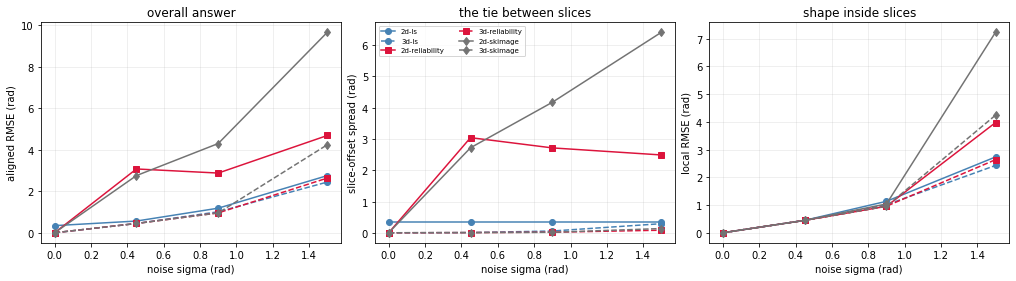

In [9]:
figure, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
styles = {'ls': ('steelblue', 'o'), 'reliability': ('crimson', 's'),
          'skimage': ('0.45', 'd')}
for family, (colour, marker) in styles.items():
    for order, dash in ((2, '-'), (3, '--')):
        key = '%dd-%s' % (order, family)
        values = [sweep[sigma][key]['aligned_rmse_rad']
                  for sigma in noise_levels]
        axes[0].plot(noise_levels, values, color=colour, marker=marker,
                     linestyle=dash, label=key)
        values = [sweep[sigma][key]['slice_offset_spread_rad']
                  for sigma in noise_levels]
        axes[1].plot(noise_levels, values, color=colour, marker=marker,
                     linestyle=dash, label=key)
        values = [sweep[sigma][key]['local_rmse_rad']
                  for sigma in noise_levels]
        axes[2].plot(noise_levels, values, color=colour, marker=marker,
                     linestyle=dash, label=key)
axes[0].set_ylabel('aligned RMSE (rad)')
axes[1].set_ylabel('slice-offset spread (rad)')
axes[2].set_ylabel('local RMSE (rad)')
for axis in axes:
    axis.set_xlabel('noise sigma (rad)')
    axis.grid(alpha=.25)
axes[1].legend(fontsize=7, ncol=2)
axes[0].set_title('overall answer')
axes[1].set_title('the tie between slices')
axes[2].set_title('shape inside slices')
plt.show()

### Reading the sweep

The table holds six strategies at four noise levels. Reading it column by column
is the fastest way to see what the third axis actually buys.

1. **It always removes the tie between slices.** In the offsets column every 3-D
   row is smaller than its 2-D twin, usually by orders of magnitude. Least
   squares: 0.344 rad becomes 0.006 at $\sigma = 0.45$, and 0.344 becomes 0.291
   at $\sigma = 1.5$. Reliability sorting: 3.042 becomes 0.006, and 2.489 becomes
   0.082. For least squares this is not a nuance but a change of model: a
   per-slice constant is a degree of freedom its 2-D form does not have, and in
   this data that constant is exactly the drift.
2. **Up to moderate noise, the shape inside a slice is unchanged.** In the local
   column at $\sigma \le 0.45$ the 2-D and 3-D numbers agree to within 0.001 rad
   for both families: 0.448 against 0.447 for least squares, 0.447 against 0.447
   for reliability. At those levels the third axis is a *registration* tool -- it
   says where the slices sit, not what happens within one. This is the correction
   to the naive expectation that more data is automatically better.
3. **Least squares keeps improving as the noise grows, because every voxel has
   one more equation.** At $\sigma = 0.9$ its local error is 1.134 slice by slice
   and 1.010 jointly; at $\sigma = 1.5$, 2.733 and 2.427. Reliability sorting
   gains nothing yet at $\sigma = 0.9$ (0.955 against 0.958) and then gains a
   great deal at $\sigma = 1.5$ (3.973 against 2.635), because that is the regime
   where slices used on their own fall apart -- 54% of their voxels are on the
   wrong fringe by then -- and the across-slice edges are the only way left to
   route around the damage. The right-hand panel shows the two shapes of gain:
   a straight line for least squares, a late drop for the tree method.
4. **No method wins everything, and the ranking moves with the noise.** At
   $\sigma = 0.9$ the smallest overall error in the table belongs to the 3-D
   scikit-image run at $0.95$, just ahead of 3-D reliability at 0.958 and 3-D
   least squares at 1.011. At $\sigma = 1.5$ the order changes: 3-D least squares
   2.445, then 3-D reliability 2.636, then 3-D scikit-image well back at
   $4.2$ -- and among the two Parvaneh families neither dominates, since the tree
   method has the smaller wrong-fringe fraction (0.163 against 0.187) while least
   squares has the smaller overall error. The two scikit-image entries are quoted
   to two decimals on purpose: as section 4 showed, that solver does not repeat
   itself below its third digit, so its place in a ranking this tight is a
   statement about the algorithm, not about the third decimal. What is stable
   across the table is the per-slice column: solving slice by slice is the
   weakest option in every family once there is noise. For least squares the
   penalty is mild and steady, about 1.1 times the joint error at $\sigma = 0.9$
   and $1.5$; for reliability sorting and for the scikit-image baseline it is
   severe while the slices are still individually sound -- 6.9 and 6.2 times at
   $\sigma = 0.45$ -- and then *shrinks* as the noise grows, to 1.8 and 2.3 times
   at $\sigma = 1.5$, simply because by then the joint solve is failing too.

The mechanism behind point 3 is worth stating, because it is not a coincidence.
Least squares solves for every voxel at once, so a sixth neighbour is another
equation for the same unknown and the noise averages down immediately.
Reliability sorting grows a tree and commits: once a voxel is attached it is
finished, and extra neighbours can only change *which* tree gets built. While the
slices are individually sound, that changes little; when they are not, having
more than one way to reach a region is what keeps the forest connected to good
ground.

## 6. What it costs

Nothing above is a speed contest, but the volume solvers differ in kind, so the
timings matter. Below, each strategy runs once on a $48 \times 48 \times 8$
volume ($18\,432$ voxels) with $\sigma = 0.45$, after one warm-up call, and we
keep the median of twenty-five runs.

In [10]:
volume_truth, volume = build_volume(48, 48, 8, 0.45, seed=1)


def candidate_pairs(shape):
    """Count the neighbouring pairs a spanning tree over this shape could use."""
    return int(sum(np.prod(shape) // n * (n - 1) for n in shape))


to_time = [('3-D least squares', lambda: unwrap(volume)),
           ('2-D least squares', lambda: per_slice(volume, unwrap)),
           ('3-D reliability, numba',
            lambda: reliability_unwrap(volume, backend='numba')),
           ('3-D reliability, python',
            lambda: reliability_unwrap(volume, backend='python')),
           ('2-D reliability, numba',
            lambda: per_slice(volume,
                              lambda s: reliability_unwrap(s,
                                                           backend='numba')))]

print('%-26s %10s' % ('strategy', 'seconds'))
seconds = {}
for name, solve in to_time:
    solve()  # one warm-up call, so compiled kernels are not timed
    _, seconds[name] = timed(solve, repeat=25)
    print('%-26s %10.3f' % (name, seconds[name]))

joint_pairs = candidate_pairs(volume.shape)
slice_pairs = volume.shape[2] * candidate_pairs(volume.shape[:2])
print('candidate pairs: joint %d, per-slice %d (ratio %.2f)'
      % (joint_pairs, slice_pairs, joint_pairs / slice_pairs))

print('reference Python is %.1f times the compiled loop'
      % (seconds['3-D reliability, python']
         / seconds['3-D reliability, numba']))
print('joint 3-D solve is %.1f times the per-slice solve'
      % (seconds['3-D reliability, numba']
         / seconds['2-D reliability, numba']))

strategy                      seconds
3-D least squares               0.005
2-D least squares               0.007
3-D reliability, numba          0.009
3-D reliability, python         0.118
2-D reliability, numba          0.007
candidate pairs: joint 52224, per-slice 36096 (ratio 1.45)
reference Python is 12.7 times the compiled loop
joint 3-D solve is 1.4 times the per-slice solve


The pattern is the expected one and it is worth naming.

* Least squares is a transform: one iteration is a pair of DCTs, so its cost
  grows roughly like $N \log N$ in the number of samples, and this volume
  finishes in milliseconds.
* Reliability sorting is a sorting problem: it visits every candidate pair once,
  so its cost grows with the number of pairs times the logarithm of the sort. The
  compiled merge stays within a small factor of least squares at this size; the
  reference Python loop is an order of magnitude slower, and it exists for
  clarity and for cross-checking the compiled path -- the cell prints both ratios.
* Doing the volume jointly is *not* dramatically worse than doing the slices
  separately. The deterministic part of the answer is in the cell: joining the
  slices adds 16 128 inter-slice pairs to the 36 096 pairs that the eight
  independent solves work through, a ratio of about 1.4. The timing column shows
  that ratio turning into a factor in the low single digits. Every entry there is
  a few milliseconds, so read that column as an order of magnitude rather than as
  a precise number; rerun the cell on your own machine if you need the numbers.

In other words, tying the slices together costs a few milliseconds and a factor in
the low single digits at this size, in exchange for removing the per-slice offsets
that are otherwise free to go wrong. That is why the package simply lets `unwrap`
and `reliability_unwrap` accept any number of axes instead of offering a separate
volume-only entry point.

## 7. Takeaways

* A volume should be unwrapped jointly when slices are genuine neighbours. The
  gain is large, it is measurable, and at moderate noise it is entirely about
  **tying the slices together** rather than about the shape inside them.
* Least squares and reliability sorting fail in different ways: least squares
  spreads disagreement, reliability sorting locks in a tree. Comparing them on a
  volume with known truth is how you find out which failure your data tolerates.
* Every claim above is reproducible from the command line:

  ```bash
  python benchmarks/benchmark_nd.py --rows 64 --cols 64 --slices 12
  pytest -q tests/test_reliability.py tests/test_unwrap.py
  ```

That is the whole point of the exercise. The third axis is a real, cheap and
sometimes decisive source of information -- provided it means something.

### Where this lives in the repository

| file | contents |
| --- | --- |
| `src/parvaneh/core.py` | `unwrap`, the least-squares Poisson solver, valid for any number of axes |
| `src/parvaneh/reliability.py` | `pixel_reliability`, `reliability_unwrap`, and the `ReliabilityInfo` bookkeeping |
| `src/parvaneh/numba_backend.py` | compiled merge loop; bit-identical to the Python reference |
| `benchmarks/benchmark_nd.py` | the command-line version of this notebook, with JSON output |
| `tests/test_reliability.py`, `tests/test_unwrap.py` | the tests that pin down every number quoted here |
| `docs/algorithms.md`, `docs/performance.md` | reference documentation for the solvers and their cost |